In [7]:
from tidy3d import material_library

print([variant for variant in material_library['SiO2'].variants])
print([variant for variant in material_library['cSi'].variants])

['Palik_Lossless', 'Palik_Lossy', 'Horiba']
['Palik_Lossless', 'Palik_Lossy', 'SalzbergVilla1957', 'Li1993_293K', 'Green2008', 'Green2008_Lossless', 'Si_MultiPhysics']


In [1]:
# Standard python imports.
import matplotlib.pylab as plt
import numpy as np
import photonforge as pf

# Import regular tidy3d
import tidy3d as td
import tidy3d.web as web

In [2]:
# MMI power splitter setup.
wavelength = 1.31  # Center simulation wavelength (um).
freq0 = td.C_0 / wavelength  # Central frequency.

In [3]:
# mat_si = td.material_library['cSi']['Li1993_293K']
mat_si = td.Medium(permittivity=3.48**2)  # Use real permittivity for mode source

# mat_sio2 = td.material_library['SiO2']['Horiba']
mat_sio2 = td.Medium(permittivity=1.44**2)  # Use real permittivity for mode source


In [4]:
# This cell contains all the geometry, sources, monitors, and simulation creation

# MMI power splitter dimensions.
w_wg = 0.38  # Waveguide width (um).
h_si = 0.22  # Silicon layer height (um).
l_straight = 5.228
gap = 0.1  # Gap between output waveguides (um).

# S-bend parameters.
s_bend_offset = 1.0  # Lateral offset for S-bends (um).
s_bend_length = 4.0  # Length of S-bend section (um).

In [5]:
def make_straight_dc_shape(
    l_straight: float,
    w_wg: float,
    gap: float,
    s_bend_length: float,
    s_bend_offset: float,
    center: tuple[float, float]=(0, 0),
    slab_bounds: tuple[float, float]=(-0.11, 0.11),
    sidewall_angle: float=0,
    reference_plane: str="top",
) -> td.PolySlab:

    straight_up = pf.Rectangle(size=(l_straight, w_wg), center=(0, w_wg / 2 + gap / 2))
    straight_down = straight_up.copy().mirror()

    x_out = l_straight / 2
    y_out = gap / 2 + w_wg / 2

    bend_out_up = pf.Path(origin=(x_out, y_out), width=w_wg)
    bend_out_up.s_bend(endpoint=(s_bend_length, s_bend_offset),
                       relative=True)  # relative: if set, the endpoint is calculated relative to the current end point of the path.
    bend_out_up.segment(endpoint=(10, 0), relative=True)

    bend_out_down = bend_out_up.copy().mirror()
    bend_in_up = bend_out_up.copy().mirror((0, 1))
    bend_in_down = bend_out_down.copy().mirror((0, 1))

    # Returns a list of Polygon objects, representing the polygons of the Paths successing the boolean operation.
    # The boolean below is the union of the first list with an empty list.
    # So the purpose was more to get the polygons from the Paths.
    polygons_up = pf.boolean(
        [
            straight_up,
            bend_out_up,
            bend_in_up,
        ],
        [],
        "+",
    )
    polygons_down = pf.boolean(
          [
            straight_down,
            bend_out_down,
            bend_in_down,
          ], [], "+")  # Empty union to get an empty list of polygons.

    # assert len(polygons) == 2, "Expected two polygon for the union."
    # polygon = polygons[0]
    # assert len(polygon.holes) == 0, "Expected no holes."
    polygon_up = polygons_up[0]
    polygon_down = polygons_down[0]
    polygon_up.translate(center)
    polygon_down.translate(center)

    # Polygon extruded with optional sidewall angle along axis direction.
    geometry_up = td.PolySlab(
        vertices=polygon_up.vertices,
        axis=2,
        slab_bounds=slab_bounds,
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    geometry_down = td.PolySlab(
        vertices=polygon_down.vertices,
        axis=2,
        slab_bounds=slab_bounds,
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )


    return geometry_up, geometry_down

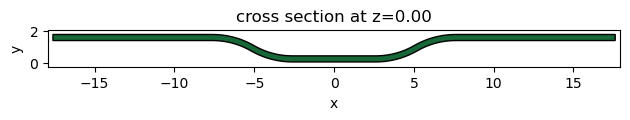

In [6]:
s_bend_length = 5

s_bend_radius = 5
theta = np.arcsin(s_bend_length/2 / s_bend_radius)

s_bend_offset = 2 * s_bend_radius * (1 - np.cos(theta))

geometry_up, geometry_down = make_straight_dc_shape(
    l_straight=l_straight, w_wg=w_wg, gap=gap, s_bend_length=s_bend_length, s_bend_offset=s_bend_offset)

# geometry_up, geometry_down = make_straight_dc_shape_circular(
#     l_straight=l_straight, w_wg=w_wg, gap=gap, R_bend=s_bend_radius, routing_half_pitch=gap/2 + w_wg/2 + 1.0)
# Turning geometry to structure
mmi_structure_up = td.Structure(geometry=geometry_up, medium=mat_si)
mmi_structure_down = td.Structure(geometry=geometry_down, medium=mat_si)
ax = mmi_structure_up.plot(z=0)

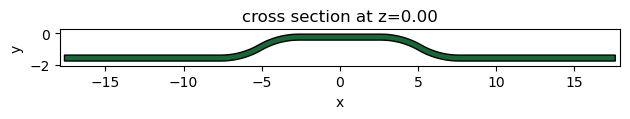

In [7]:
ax = mmi_structure_down.plot(z=0)


In [8]:
# Calculate optimized simulation domain size for x-axis propagation.
x_min = -1.5 - 3.0  # -4.5 um, this is not actually the x-min, the actual one is going to be -total_length/2
x_max = 5.5 + 3.0  # 8.5 um
total_length = 20
total_width = 2*s_bend_offset + gap + 4.0  # Keep width buffer for offset waveguides
total_height = 2.0  # Sufficient for SOI structure
sim_size_optimized = (total_length, total_width, total_height)

wavelengths = np.arange(1.27, 1.35, 0.01)  # 1.27 to 1.35 μm with 10 nm steps
frequencies = td.C_0 / wavelengths

# ===================
# Source Definition
source_position = (-l_straight/2-s_bend_length - 0.5, gap/2 + s_bend_offset + w_wg/2, 0)
source_size = (0, 6 * w_wg, 6 * h_si)
for i, (s, sim) in enumerate(zip(source_size, sim_size_optimized)):
    assert s <= sim, f"Dimension {i} too large: {s} > {sim}"

mode_source = td.ModeSource(
    center=source_position,
    size=source_size,
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
    direction="+",
    mode_spec=td.ModeSpec(num_modes=1),
    mode_index=0,
)
# ===================

# ===================
# Monitors Definition
# 1) Through monitor
monitor_1_position = (l_straight / 2 + s_bend_length + 0.5, w_wg / 2 + gap / 2 + s_bend_offset, 0)
mode_monitor_1 = td.ModeMonitor(
    center=monitor_1_position,
    size=source_size,
    freqs=frequencies,
    mode_spec=td.ModeSpec(num_modes=1),
    name="mode_output_1",
)
# 2) Cross monitor
monitor_2_position = (l_straight / 2 + s_bend_length + 0.5, -w_wg / 2 - gap / 2 - s_bend_offset, 0)
mode_monitor_2 = td.ModeMonitor(
    center=monitor_2_position,
    size=source_size,
    freqs=frequencies,
    mode_spec=td.ModeSpec(num_modes=1),
    name="mode_output_2",
)
# 3) "cross-section" monitor to visualize field distribution throughout the MMI.
# 11. Field monitor at xy plane - record fields at specific wavelengths (x-axis propagation).
field_freqs = [td.C_0 / wavelengths[-1], td.C_0 / wavelengths[0]]  # 1.55 and 1.58 um
field_monitor = td.FieldMonitor(
    center=(0, 0, 0), size=(td.inf, td.inf, 0), freqs=field_freqs, name="field_xy"
)

print("Source and monitors defined.")
print(f"Source position: {source_position}")
print(f"Monitor 1 position: {monitor_1_position}")
print(f"Monitor 2 position: {monitor_2_position}")
print(sim_size_optimized)

Source and monitors defined.
Source position: (-8.114, np.float64(1.579745962155614), 0)
Monitor 1 position: (8.114, np.float64(1.579745962155614), 0)
Monitor 2 position: (8.114, np.float64(-1.579745962155614), 0)
(20, np.float64(6.779491924311229), 2.0)


In [9]:
# 12. Create the complete simulation.
sim_mmi = td.Simulation(
    size=sim_size_optimized,
    structures=[mmi_structure_up, mmi_structure_down],
    sources=[mode_source],
    monitors=[mode_monitor_1, mode_monitor_2, field_monitor],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    medium=mat_sio2,
    grid_spec=td.GridSpec(
        grid_x=td.AutoGrid(min_steps_per_wvl=20),
        grid_y=td.AutoGrid(min_steps_per_wvl=20),
        grid_z=td.AutoGrid(min_steps_per_wvl=20),
        wavelength=wavelength,
    ),
    symmetry=(0, 0, 0),
)

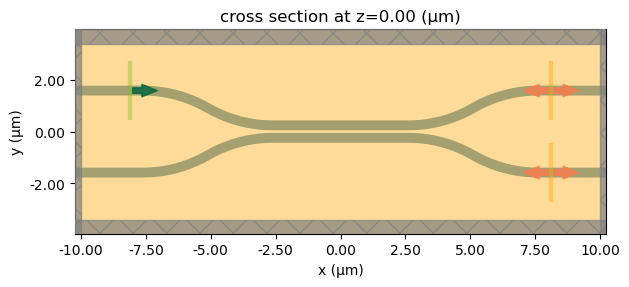

In [10]:
# Simulation Setup Visualization - XY Setup Plane
fig_xy = sim_mmi.plot(z=0)  # XY cross-section at z=0 (MMI center) - shows complete setup

In [11]:
# 3D Visualization
fig_3d = sim_mmi.plot_3d()

In [12]:
# Run Simulation
job = web.Job(simulation=sim_mmi, task_name="dc_straight", verbose=True)

sim_data = job.run(path="dc_straight_results.hdf5")

08:23:42 CEST Loading simulation from local cache. View cached task using web UI
              at                                                                
              ]8;id=914856;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aa045894-c0c5-40e0-be9d-451b6cfdc57b\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=85694;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aa045894-c0c5-40e0-be9d-451b6cfdc57b\taskId]8;;\]8;id=914856;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aa045894-c0c5-40e0-be9d-451b6cfdc57b\=]8;;\]8;id=851990;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aa045894-c0c5-40e0-be9d-451b6cfdc57b\fdve]8;;\]8;id=914856;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aa045894-c0c5-40e0-be9d-451b6cfdc57b\-aa045894-c0]8;;\
              ]8;id=914856;https://tidy3d.simulation.cloud/workbench?taskId=fdve-aa045894-c0c5-40e0-be9d-451b6cfdc57b\c5-40e0-be9d-451b6cfdc57b']8;;\.

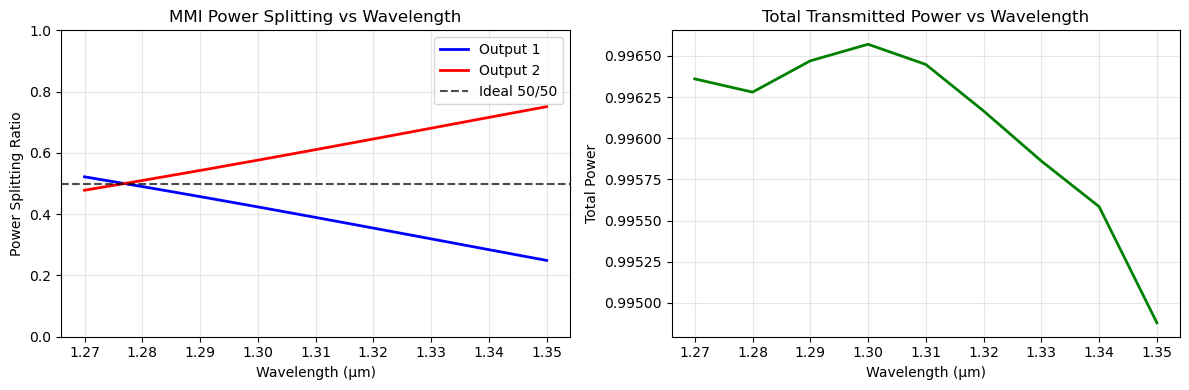

Average splitting ratio 1: 0.388
Average splitting ratio 2: 0.612
Average total power: 0.996


In [15]:
# Extract mode coefficients from ModeMonitors
mode_coeff_1 = sim_data["mode_output_1"].amps.sel(mode_index=0, direction="+")
mode_coeff_2 = sim_data["mode_output_2"].amps.sel(mode_index=0, direction="+")

# Calculate power splitting
power_1 = np.abs(mode_coeff_1) ** 2
power_2 = np.abs(mode_coeff_2) ** 2
total_power = power_1 + power_2

# Calculate splitting ratio
splitting_ratio_1 = power_1 / total_power
splitting_ratio_2 = power_2 / total_power

# Ensure arrays are numpy arrays for consistent indexing
splitting_ratio_1 = np.array(splitting_ratio_1)
splitting_ratio_2 = np.array(splitting_ratio_2)
total_power = np.array(total_power)

# Create comprehensive analysis plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Power splitting vs wavelength
ax1.plot(wavelengths, splitting_ratio_1, "b-", label="Output 1", linewidth=2)
ax1.plot(wavelengths, splitting_ratio_2, "r-", label="Output 2", linewidth=2)
ax1.axhline(y=0.5, color="k", linestyle="--", alpha=0.7, label="Ideal 50/50")
ax1.set_xlabel("Wavelength (μm)")
ax1.set_ylabel("Power Splitting Ratio")
ax1.set_title("MMI Power Splitting vs Wavelength")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Total power vs wavelength
ax2.plot(wavelengths, total_power, "g-", linewidth=2)
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel("Total Power")
ax2.set_title("Total Transmitted Power vs Wavelength")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key performance metrics
print(f"Average splitting ratio 1: {splitting_ratio_1.mean():.3f}")
print(f"Average splitting ratio 2: {splitting_ratio_2.mean():.3f}")
print(f"Average total power: {total_power.mean():.3f}")

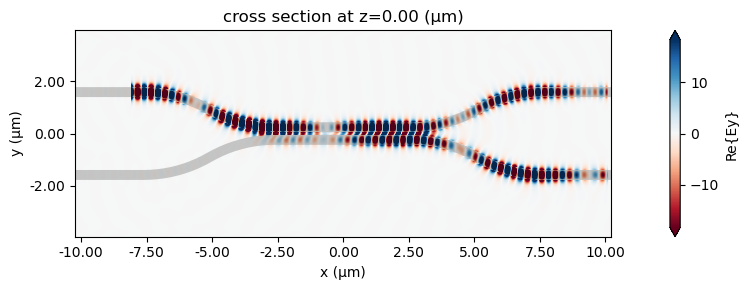

In [14]:
fig, ax = plt.subplots(1,1,figsize=(12, 3), tight_layout=True)

sim_data.plot_field('field_xy', 'Ey', z=0, f=freq0, val='real', ax = ax)
# sim_point_data.plot_field('field', 'Ey', z=0, f=freq0, val='real', ax = ax[1])
# ax[0].set_xlim([-10,0])
# ax[1].set_xlim([-10,0])
plt.show()